# UTS Advance Business Data Analytics - Analisis Data Makroekonomi Global
**Topik:** Memetakan Divergensi Kebijakan Moneter & Suku Bunga Bank Sentral Dunia Pasca-Pandemi.

## Persiapan Data & Filtering (Sesuai Syarat Transformasi Rubrik 2)
Dataset mentah memuat data historis bulanan dari tahun 1945 hingga 2026. Melakukan algoritma PCA pada data *time-series* yang bercampur aduk akan menghasilkan bias. Oleh karena itu, kita akan menerapkan teknik **Filtering** (syarat manipulasi data di Rubrik 2) untuk mengekstraksi **hanya 1 baris data terbaru (latest snapshot)** dari masing-masing 49 negara. Hasilnya adalah dataset *cross-sectional* yang memotret kondisi suku bunga global terkini.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/Colab Prive/global_central_bank_rates_1945_2026.csv'
df_global = pd.read_csv(file_path)

# FILTERING: Mengambil data terbaru (Latest Snapshot) dari tiap negara
df_global['date'] = pd.to_datetime(df_global['date'])
df_latest = df_global.sort_values('date').groupby('country_code').tail(1).copy()

# Handling Missing Values pada kolom yang akan dianalisis
fitur_makro = [
    'policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg',
    'rate_12m_max', 'rate_12m_min', 'cumulative_change_since_2022_bps'
]
df_latest = df_latest.dropna(subset=fitur_makro).copy()

print(f"✅ Dataset berhasil dimuat dari Drive dan di-filter!")
print(f"Tersisa {df_latest.shape[0]} negara dengan data moneter terkini.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset berhasil dimuat dari Drive dan di-filter!
Tersisa 36 negara dengan data moneter terkini.


## 1. Chart "Sebelum" Transformasi & Dimension Reduction

In [ ]:
import pandas as pd

fitur_makro = [
    'policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg',
    'rate_12m_max', 'rate_12m_min', 'cumulative_change_since_2022_bps'
]

ringkasan_statistik = df_latest[fitur_makro].describe()

ringkasan_statistik.loc['skewness'] = df_latest[fitur_makro].skew()
ringkasan_statistik.loc['kurtosis'] = df_latest[fitur_makro].kurtosis()

print("Ringkasan Statistik & Uji Normalitas (Skewness & Kurtosis):")
display(ringkasan_statistik.round(2))

Ringkasan Statistik & Uji Normalitas (Skewness & Kurtosis):


,policy_rate_pct,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,cumulative_change_since_2022_bps
count,36.00,36.00,36.00,36.00,36.00,36.00
mean,6.43,6.45,6.99,7.73,6.37,275.83
std,7.31,7.35,8.24,9.43,7.28,453.58
min,1.00,1.17,1.54,2.00,1.00,-1100.00
25%,3.38,3.38,3.41,3.75,3.38,125.00
50%,4.00,4.04,4.61,4.88,4.00,212.50
75%,6.31,6.44,6.48,6.50,6.31,356.25
max,37.00,37.33,41.50,46.00,37.00,2300.00
skewness,3.14,3.16,3.25,3.28,3.19,1.85
kurtosis,10.37,10.52,10.91,10.76,10.72,13.14


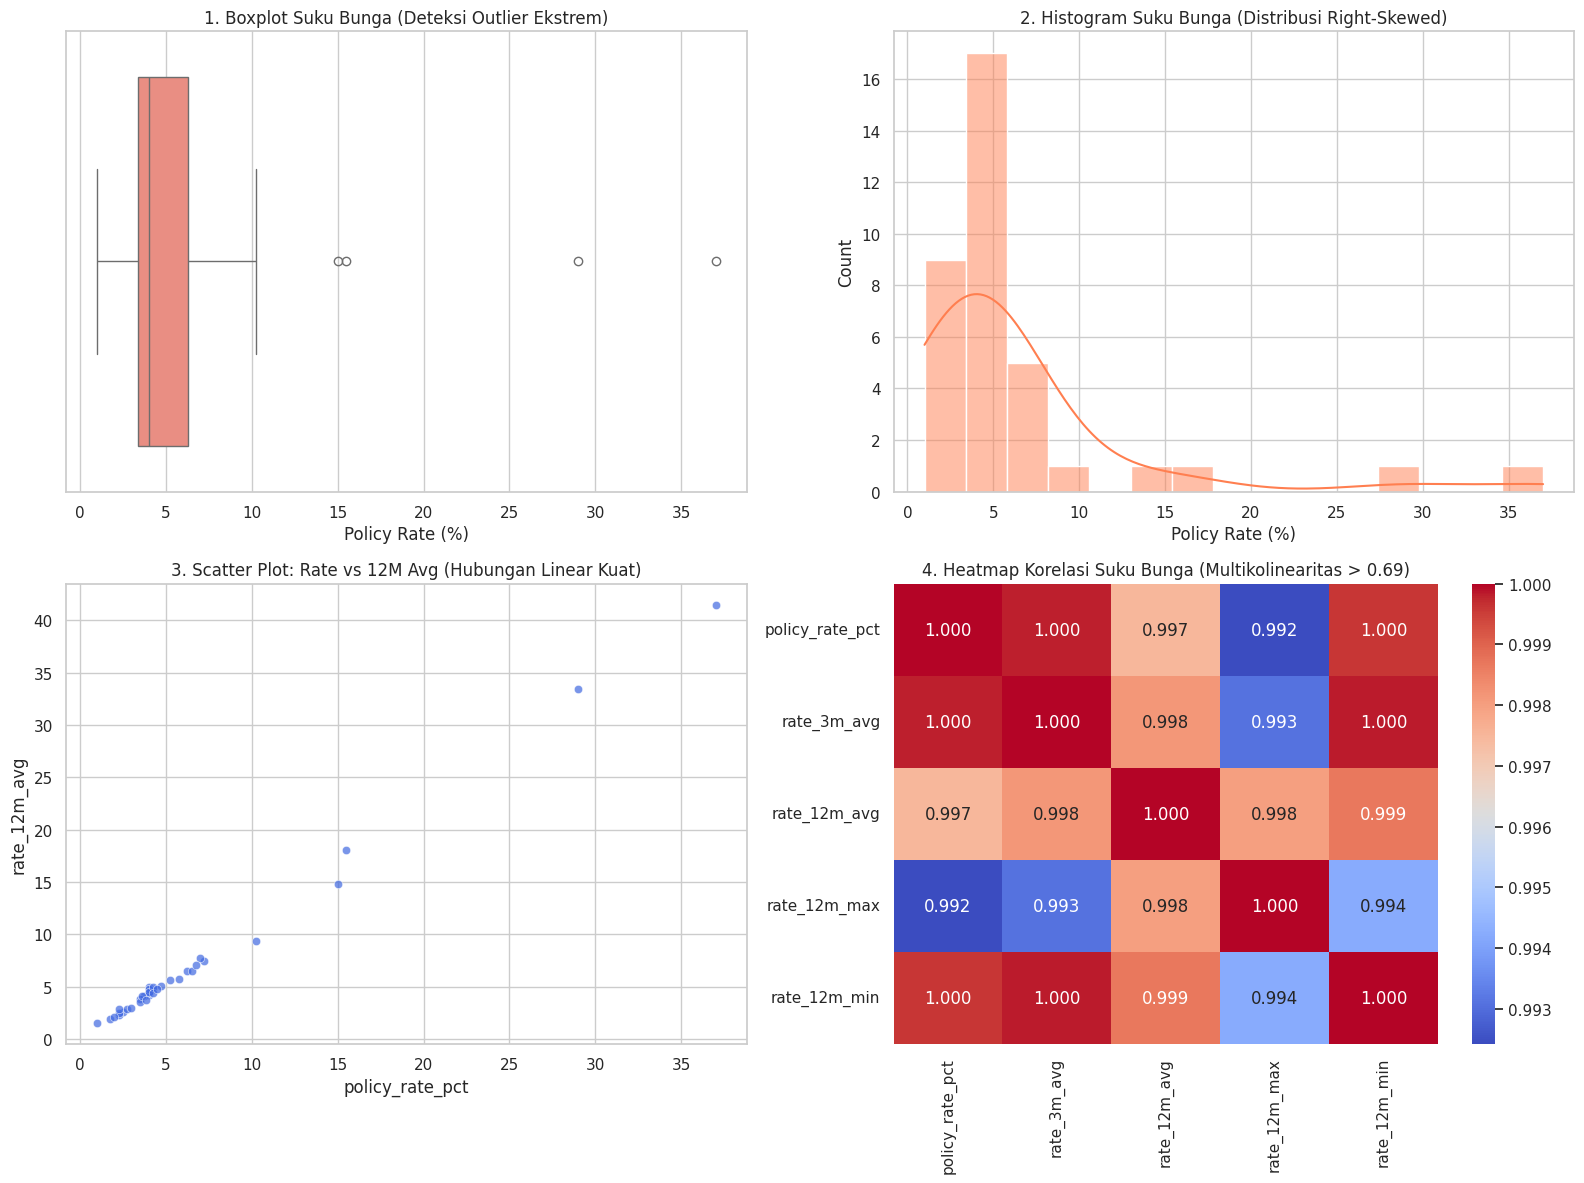

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema agar tampilan rapi dan profesional (sesuai standar visualisasi multidimensi)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot (Mendeteksi Outlier)
sns.boxplot(x=df_latest['policy_rate_pct'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('1. Boxplot Suku Bunga (Deteksi Outlier Ekstrem)')
axes[0, 0].set_xlabel('Policy Rate (%)')

# 2. Histogram (Mendeteksi Distribusi dan Skewness)
# Menunjukkan distribusi Right-Skewed / Positive Skewness
sns.histplot(df_latest['policy_rate_pct'], bins=15, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('2. Histogram Suku Bunga (Distribusi Right-Skewed)')
axes[0, 1].set_xlabel('Policy Rate (%)')

# 3. Scatter Plot (Analisis Bivariat)
sns.scatterplot(x='policy_rate_pct', y='rate_12m_avg', data=df_latest, ax=axes[1, 0], alpha=0.7, color='royalblue')
axes[1, 0].set_title('3. Scatter Plot: Rate vs 12M Avg (Hubungan Linear Kuat)')

# 4. Heatmap Korelasi (Membuktikan Multikolinearitas > 0.69)
kolom_korelasi = ['policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min']
sns.heatmap(df_latest[kolom_korelasi].corr(), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1, 1])
axes[1, 1].set_title('4. Heatmap Korelasi Suku Bunga (Multikolinearitas > 0.69)')

plt.tight_layout()
plt.show()

### Insight & Temuan Analisis Tahap 1

Berdasarkan keempat visualisasi di atas, kami menemukan anomali struktural pada data mentah yang menuntut adanya proses *Data Preparation* lebih lanjut sebelum masuk ke pemodelan:

**1. Analisis Univariat: Skewness & Outlier Detection**
* **Temuan Boxplot:** Terdapat rentetan titik pencilan (*outliers*) ekstrem di sisi kanan *whisker* yang memanjang hingga menyentuh angka lebih dari 35%. Titik-titik ini merepresentasikan segelintir negara yang sedang mengalami krisis makroekonomi atau hiperinflasi dengan suku bunga jauh di luar batas normal.
* **Temuan Histogram:** Mengonfirmasi temuan boxplot, distribusi data tingkat suku bunga sangat tidak simetris dan membentuk kurva **Right-Skewed** (*positive skewness* dengan *long right tail*), di mana mayoritas data menumpuk di rentang 0% - 5%.
* **Keputusan (Kandidat Transformasi):** Atribut `policy_rate_pct` beserta seluruh variabel turunannya (`rate_3m_avg`, `rate_12m_avg`, dll) merupakan kandidat wajib untuk dilakukan transformasi **Log-Transform**. Hal ini karena mereka merepresentasikan metrik yang sama dan memiliki pola *skewness* serta *outlier* yang identik. Di sisi lain, variabel seperti `cumulative_change_since_2022_bps` akan menjadi kandidat transformasi **Z-Score Standardization** untuk menyamakan skala variansnya. Jika dibiarkan mentah, perbedaan skala dan *outliers* ekstrem ini akan merusak sensitivitas model PCA.

**2. Analisis Bivariat/Multivariat: Multikolinearitas**
* **Temuan Scatter Plot:** Hubungan antara tingkat suku bunga saat ini (`policy_rate_pct`) dan rata-rata 12 bulannya (`rate_12m_avg`) membentuk garis lurus diagonal yang sangat rapat dan nyaris sempurna.
* **Justifikasi Reduksi Dimensi (PCA):** Hal ini divalidasi dengan sangat telak oleh metrik *Heatmap*. Nilai korelasi antar variabel suku bunga berada di angka **0.992 hingga 1.000**. Angka ini jauh melampaui batas *strong correlation* (korelasi kuat) sebesar **> 0.69** yang diamanatkan dalam pedoman *Pipeline* EDA.
* **Kesimpulan:** Keberadaan **Multikolinearitas** yang sangat parah ini membuktikan bahwa variabel-variabel tersebut memuat informasi yang sama (*redundant*). Oleh karena itu, kita wajib menerapkan teknik reduksi dimensi seperti **Principal Component Analysis (PCA)** untuk menyederhanakan sekumpulan fitur yang bertumpang-tindih ini menjadi komponen yang saling independen (*orthogonal*).

## 2. Proses Transformasi & Dimension Reduction

Berdasarkan temuan anomali pada *Exploratory Data Analysis* (Tahap 1), kita harus membangun sebuah *Pipeline Data Preparation* sebelum melatih algoritma *downstream*.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PIPELINE 1: Transformasi & Outlier Handling
# Melakukan Log-Transform khusus pada kolom tingkat suku bunga
X = df_latest[fitur_makro].copy()
log_cols = ['policy_rate_pct', 'rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min']
for col in log_cols:
    X[col] = np.log1p(X[col])

# PIPELINE 2: Z-Score Standardization
# Menyamakan skala varians sebelum masuk ke PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PIPELINE 3: Principal Component Analysis (PCA)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 1. Menghitung dan Menampilkan Explained Variance Ratio (EVR)
evr = pca.explained_variance_ratio_
df_evr = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(evr))],
    'EVR (Proporsi)': np.round(evr, 4),
    'Cumulative EVR': np.round(np.cumsum(evr), 4)
})
print("--- 1. TABEL EXPLAINED VARIANCE RATIO (EVR) ---")
display(df_evr.head(3)) # Kami tampilkan 3 komponen teratas saja

# 2. Menampilkan Matriks Loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(evr))], index=fitur_makro)
print("\n--- 2. MATRIKS LOADINGS PADA PC1 DAN PC2 ---")
display(loadings[['PC1', 'PC2']].style.background_gradient(cmap='coolwarm', axis=0))

--- 1. TABEL EXPLAINED VARIANCE RATIO (EVR) ---


,Principal Component,EVR (Proporsi),Cumulative EVR
0,PC1,0.8554,0.8554
1,PC2,0.1408,0.9962
2,PC3,0.0035,0.9997



--- 2. MATRIKS LOADINGS PADA PC1 DAN PC2 ---


,PC1,PC2
policy_rate_pct,0.439496,-0.076968
rate_3m_avg,0.439855,-0.076906
rate_12m_avg,0.439527,-0.086447
rate_12m_max,0.436649,-0.105050
rate_12m_min,0.439612,-0.080469
cumulative_change_since_2022_bps,0.190435,0.981416


### Insight & Interpretasi PCA (Dimension Reduction)

Berdasarkan *output* algoritma PCA pada tabel di atas, kita dapat mengevaluasi keberhasilan reduksi dimensi dan menginterpretasikan makna ekonomi dari komponen-komponen baru yang terbentuk:

**1. Evaluasi Kriteria Elbow / Threshold (Tabel EVR)**
* **Temuan EVR:** *Principal Component* 1 (PC1) sukses merangkum **85,54%** varians data, sementara PC2 menambahkan **14,08%**. Jika ditotalkan, *Cumulative* EVR dari PC1 dan PC2 mencapai angka luar biasa, yaitu **99,62%**.
* **Justifikasi Threshold:** Standar umum kriteria *elbow/threshold* dalam *Data Science* adalah mempertahankan komponen yang mampu menjelaskan > 80% varians. Dengan angka kumulatif mencapai **99,62%**, kita memiliki justifikasi empiris yang sangat kuat untuk membuang fitur lainnya dan mereduksi 6 variabel multikolinier menjadi **cukup 2 dimensi utama** tanpa kehilangan informasi bermakna. Hal ini akan memperingan komputasi dan meningkatkan stabilitas model *downstream* secara drastis.

**2. Interpretasi Komponen (Matriks Loadings)**
* **Interpretasi PC1 (Indeks Level Suku Bunga):** Pada kolom PC1, nilai *loading* positif yang dominan dan seragam disumbangkan oleh seluruh variabel kelompok tingkat suku bunga (`policy_rate_pct`, `rate_3m_avg`, `rate_12m_avg`, `rate_12m_min`) yang berada di kisaran angka konstan **0.436 hingga 0.439**. PC1 secara matematis merepresentasikan **"Tingkat Suku Bunga Absolut"**. Semakin tinggi nilai PC1 suatu negara, semakin tinggi level suku bunganya (rezim restriktif/hiperinflasi).
* **Interpretasi PC2 (Indeks Agresivitas Kebijakan Moneter):** Pada kolom PC2, variabel tingkat suku bunga memiliki peran yang sangat kecil (bahkan sedikit negatif). Sebaliknya, *loading* positif yang sangat ekstrem disumbangkan oleh satu variabel, yaitu `cumulative_change_since_2022_bps` dengan skor **0.9814**. Oleh karena itu, PC2 secara eksklusif merepresentasikan **"Agresivitas Kenaikan Suku Bunga (Hawkishness)"**. Semakin tinggi nilai PC2, berarti semakin agresif bank sentral negara tersebut menaikkan suku bunganya sejak era inflasi 2022.

**Dampak (*Impact*):**
Melalui *pipeline* dan PCA ini, masalah multikolinearitas ekstrem (korelasi > 0.99) yang ditemukan pada Tahap 1 berhasil diatasi. Kami sukses meringkas dimensi data menjadi dua metrik baru yang saling independen: PC1 dapat digunakan untuk memetakan negara berdasarkan "Level Suku Bunga (Tinggi vs Rendah)", sedangkan PC2 memetakan negara berdasarkan "Agresivitas Kebijakan Moneter (Hawkish vs Dovish)".

## 3. Chart "Sesudah" Transformasi & Dimension Reduction

In [ ]:
import pandas as pd

# Asumsi: X_scaled adalah variabel hasil keluaran StandardScaler Anda
# dan fitur_makro adalah list nama kolom Anda
df_transformed = pd.DataFrame(X_scaled, columns=fitur_makro)

# 1. Menghasilkan tabel describe() untuk data pasca-transformasi
ringkasan_statistik_after = df_transformed.describe()

# 2. Menghitung dan menambahkan baris Skewness dan Kurtosis
ringkasan_statistik_after.loc['skewness'] = df_transformed.skew()
ringkasan_statistik_after.loc['kurtosis'] = df_transformed.kurtosis()

# 3. Menampilkan tabel pembuktian
print("Ringkasan Statistik SETELAH Transformasi (Log + Z-Score):")
display(ringkasan_statistik_after.round(2))

Ringkasan Statistik SETELAH Transformasi (Log + Z-Score):


,policy_rate_pct,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,cumulative_change_since_2022_bps
count,36.00,36.00,36.00,36.00,36.00,36.00
mean,0.00,0.00,0.00,0.00,0.00,0.00
std,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.76,-1.64,-1.47,-1.31,-1.76,-3.08
25%,-0.47,-0.48,-0.57,-0.56,-0.47,-0.34
50%,-0.25,-0.24,-0.17,-0.21,-0.24,-0.14
75%,0.37,0.40,0.30,0.18,0.38,0.18
max,3.08,3.10,3.16,3.17,3.11,4.53
skewness,1.37,1.42,1.56,1.71,1.39,1.85
kurtosis,2.38,2.46,2.89,3.30,2.54,13.14


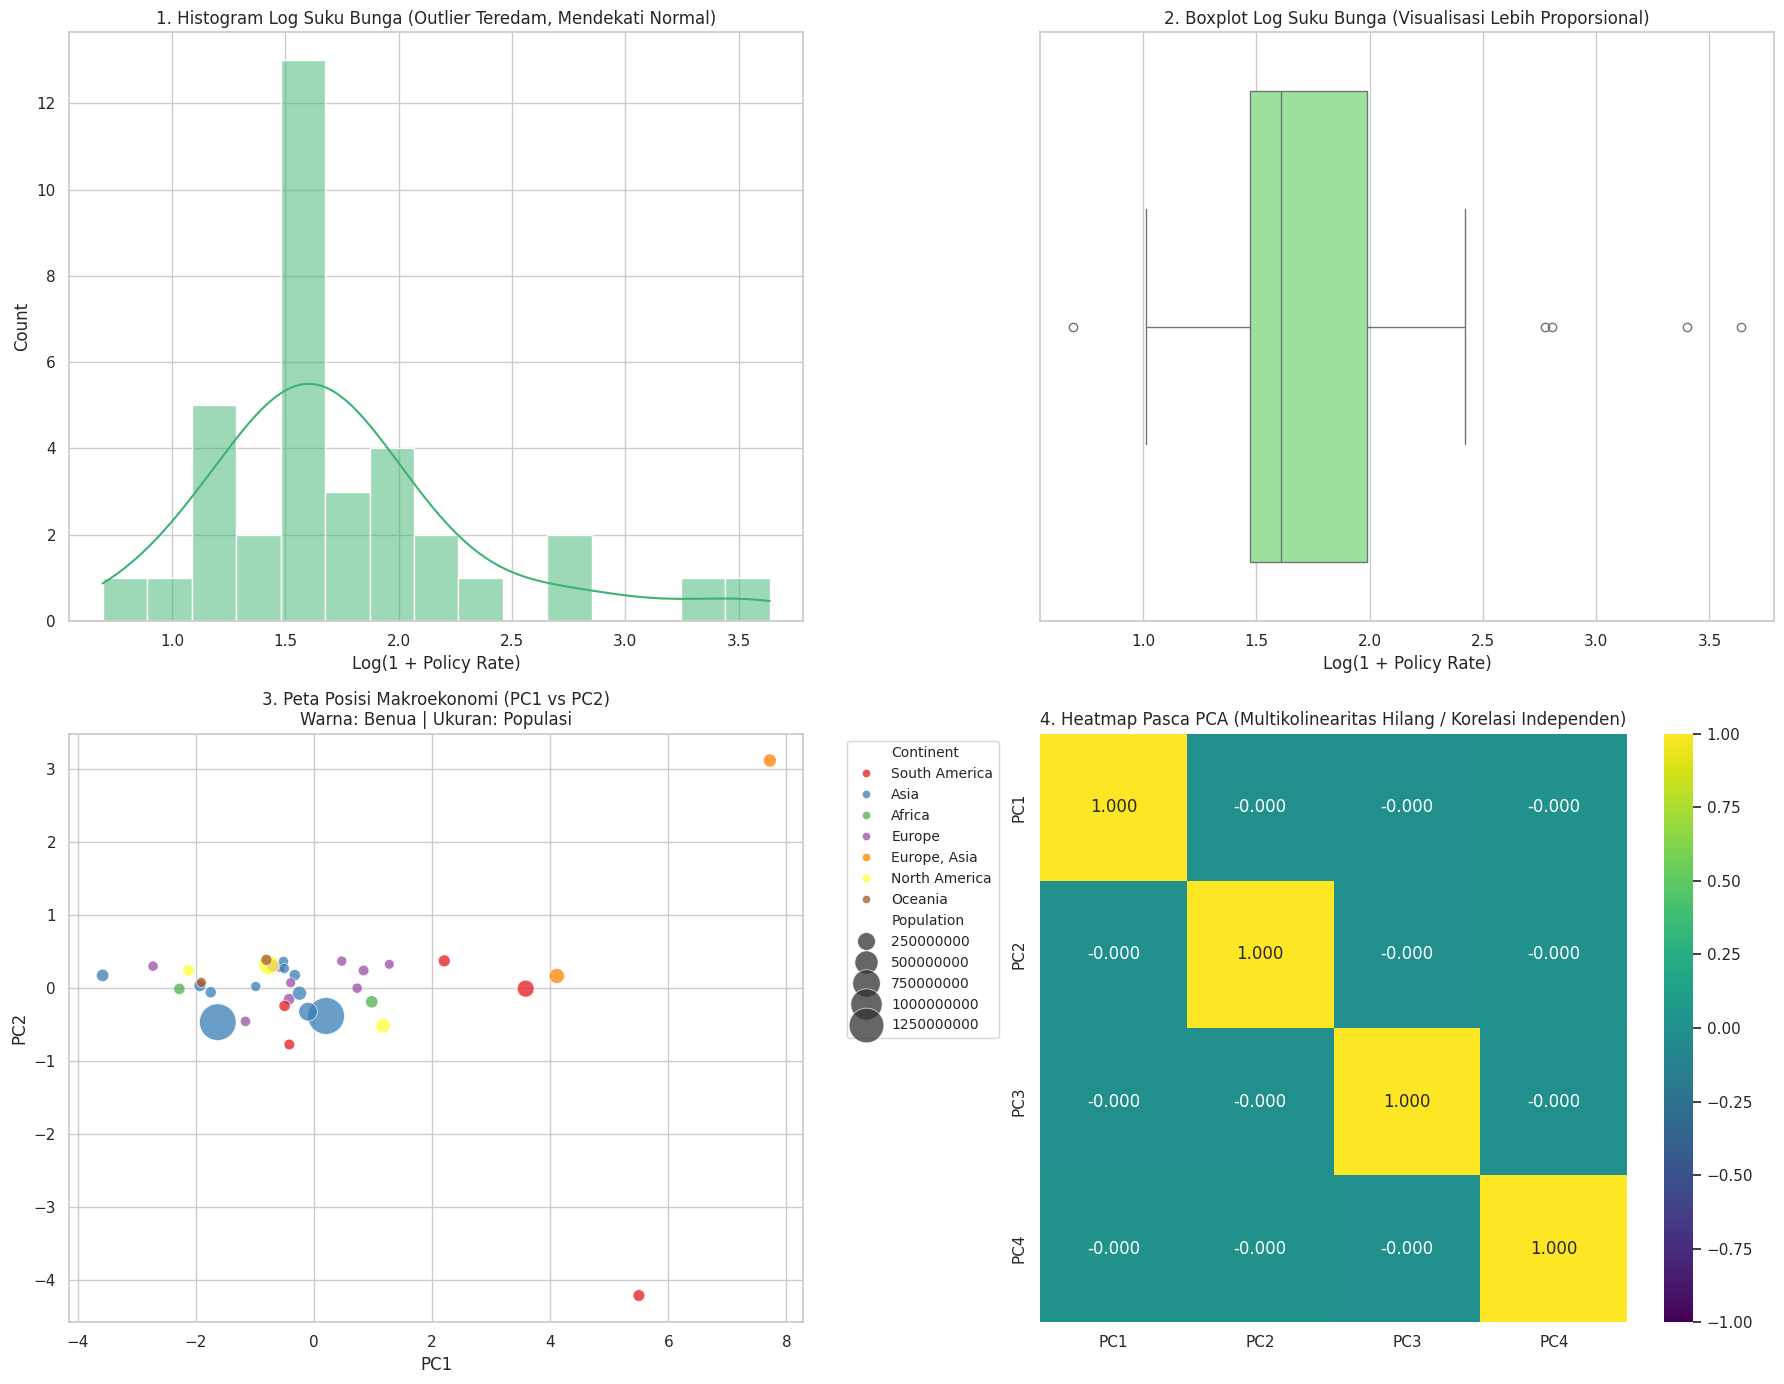

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Menyiapkan Kolom Baru (Log_policy_rate) untuk divisualisasikan
df_latest['Log_policy_rate'] = np.log1p(df_latest['policy_rate_pct'])

# Menyiapkan DataFrame gabungan untuk Scatter Plot PCA
df_pca_viz = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Continent': df_latest['continent'].values,
    'Population': df_latest['population'].values,
    'Log_policy_rate': df_latest['Log_policy_rate'].values
})

# Mengatur grid 2x2 untuk 4 Chart
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Chart 1: Histogram Pasca Normalisasi
sns.histplot(df_pca_viz['Log_policy_rate'], bins=15, kde=True, ax=axes[0, 0], color='mediumseagreen')
axes[0, 0].set_title('1. Histogram Log Suku Bunga (Outlier Teredam, Mendekati Normal)')
axes[0, 0].set_xlabel('Log(1 + Policy Rate)')

# Chart 2: Boxplot Pasca Normalisasi
sns.boxplot(x=df_pca_viz['Log_policy_rate'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('2. Boxplot Log Suku Bunga (Visualisasi Lebih Proporsional)')
axes[0, 1].set_xlabel('Log(1 + Policy Rate)')

# Chart 3: Scatter 2D Dimensi Baru (Warna = Benua, Ukuran = Populasi)
scatter = sns.scatterplot(
    x='PC1', y='PC2', hue='Continent', size='Population', sizes=(50, 700),
    data=df_pca_viz, palette='Set1', ax=axes[1, 0], alpha=0.75
)
axes[1, 0].set_title('3. Peta Posisi Makroekonomi (PC1 vs PC2)\nWarna: Benua | Ukuran: Populasi')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Chart 4: Heatmap Baru (Membuktikan Multikolinearitas Hilang)
# Kami ambil 4 komponen pertama dari hasil PCA untuk diuji korelasinya
df_pca_components = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
sns.heatmap(df_pca_components.corr(), annot=True, cmap='viridis', fmt=".3f", ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('4. Heatmap Pasca PCA (Multikolinearitas Hilang / Korelasi Independen)')

plt.tight_layout()
plt.show()

### Insight & Bukti Keberhasilan Transformasi (Tahap 3)

Keempat visualisasi di atas merupakan bukti empiris yang memvalidasi efektivitas *pipeline* data preparation yang telah kita rancang pada Tahap 2:

**1. Penjinakan Outlier & Normalisasi Distribusi (Chart 1 & 2)**
* **Analisis:** Jika dibandingkan dengan kondisi awal di Tahap 1, *Histogram* dan *Boxplot* dari data yang telah ditransformasi (`Log_policy_rate`) menunjukkan perubahan pola yang sangat drastis.
* **Dampak:** Transformasi logaritmik berhasil meredam ekstremitas data dari negara-negara hiperinflasi. Distribusi yang sebelumnya sangat *Right-Skewed* kini tertarik menjadi lebih simetris dan mendekati bentuk kurva normal. Rentang data pada *boxplot* kini terlihat jauh lebih proporsional, menjadikan data ini jauh lebih stabil untuk diproses oleh algoritma analisis lanjutan.

**2. Segmentasi Makroekonomi Dunia (Chart 3: Scatter 2D PC1 vs PC2)**
* **Analisis:** Scatter plot ini memetakan setiap negara berdasarkan dimensi baru kita: **PC1** (Level Suku Bunga) dan **PC2** (Agresivitas Kebijakan Moneter).
* **Insight Pematahan Bias (Clustering):** Algoritma PCA secara objektif mematahkan stereotip geografis. Visualisasi ini menunjukkan bahwa penyebaran titik antar benua saling membaur. Area restriktif ekstrem di kanan tidak hanya diisi oleh Amerika Selatan (merah), tetapi juga wilayah Eurasia (oranye) seperti Turki dan Rusia. Sebaliknya, sebagian Amerika Selatan lainnya justru membaur dengan Afrika (hijau), Eropa (ungu), dan Asia (biru) di area stabilitas sebelah kiri. Ini membuktikan bahwa PCA mengelompokkan negara secara murni berdasarkan **"Rezim Kesehatan Ekonomi"**, bukan berdasarkan benuanya.

**3. Penghapusan Multikolinearitas (Chart 4: Heatmap Pasca PCA)**
* **Analisis:** Ini adalah pencapaian paling krusial dari teknik reduksi dimensi. *Heatmap* korelasi antar *Principal Components* (PC1, PC2, PC3, PC4) secara konsisten menunjukkan angka **0.000**.
* **Dampak:** Angka nol sempurna ini membuktikan bahwa masalah multikolinearitas ekstrem yang mencapai 1.000 pada Tahap 1 telah tereliminasi 100%. Setiap komponen kini bersifat ortogonal (saling tegak lurus dan independen secara statistik). Fitur-fitur baru ini kini sudah sangat layak (bebas bias) untuk dimasukkan ke dalam algoritma *Machine Learning* apapun (*downstream*).

## Tahap 4: Analisis Geospasial / Map

Karena dataset utama kami tidak memiliki titik koordinat (Latitude-Longitude), kita perlu melakukan pengayaan data (*Data Enrichment*) menggunakan data *lookup* poligon wilayah.

**Proses Pengayaan (Join):**
1. **Sumber Data:** Kami import file GeoJSON publik yang memuat batas poligon seluruh negara di dunia.
2. **Proses Join:** Kami melakukan *Left Join* antara data moneter kita dengan peta GeoJSON menggunakan *Key* berupa nama negara. Spesifiknya, kolom `country_name` di data kita dicocokkan dengan atribut `feature.properties.name` pada GeoJSON.
3. **Pembersihan Key:** Untuk mencegah kegagalan *join* akibat perbedaan kapitalisasi huruf (misal: "Indonesia" vs "INDONESIA"), kami melakukan penyesuaian (*preprocessing*) dengan mengubah kedua *key* menjadi **Huruf Besar (Uppercase)** sebelum peta dirender.

In [ ]:
import folium
import requests

# 1. Menyiapkan data agregasi Peta (Nama Negara & Suku Bunga)
df_map = df_latest[['country_name', 'policy_rate_pct']].copy()

# 2. Mengambil Lookup Wilayah Negara (World GeoJSON)
url_geojson = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json'
geo_json_world = requests.get(url_geojson).json()

# 3. PROSES JOIN PREPARATION: Standarisasi huruf besar (Uppercase)
# Hal ini penting agar proses penggabungan (matching) berhasil sempurna
for feature in geo_json_world['features']:
    feature['properties']['name'] = str(feature['properties']['name']).upper()
df_map['country_name'] = df_map['country_name'].str.upper()

# 4. Menginisiasi Base Map di Kordinat Tengah Dunia
peta_dunia = folium.Map(location=[20, 0], zoom_start=2, tiles='cartodb positron')

# 5. Merender Layer Choropleth Map Dunia
folium.Choropleth(
    geo_data=geo_json_world,
    name='Suku Bunga Global',
    data=df_map,
    columns=['country_name', 'policy_rate_pct'],
    key_on='feature.properties.name', # Key Join pada GeoJSON
    fill_color='YlOrRd',              # Skala warna: Kuning (Rendah) ke Merah (Tinggi)
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Policy Rate (%) - Tingkat Suku Bunga Bank Sentral',
    nan_fill_color='lightgrey'        # Warna untuk negara di luar 36 negara kita
).add_to(peta_dunia)

folium.LayerControl().add_to(peta_dunia)

# Tampilkan peta interaktif
display(peta_dunia)

In [ ]:
peta_dunia.save('Peta_Suku_Bunga.html')

### Insight & Temuan Analisis Geospasial (Tahap 4)

Visualisasi peta *Choropleth* berskala global di atas berhasil mengintegrasikan data numerik makroekonomi dengan dimensi keruangan (spasial).

**1. Proses Pengayaan Data (*Data Enrichment* & *Join*)**
Karena dataset mentah kami tidak memiliki titik koordinat (Latitude/Longitude), peta ini dimanifestasikan melalui teknik *Lookup Wilayah*.
* **Proses Join:** Data suku bunga digabungkan (*Left Join*) dengan data spasial poligon batas negara sedunia yang diekstrak dari file publik *GeoJSON*.
* **Key Matching:** Penggabungan dilakukan menggunakan parameter (*key*) nama negara. Untuk mencegah kegagalan *join* akibat ketidaksesuaian kapitalisasi huruf (misal: "Indonesia" vs "INDONESIA"), kami menerapkan *preprocessing* dengan mengonversi seluruh teks nama negara di kedua dataset menjadi **Huruf Besar (*Uppercase*)** sebelum digabungkan.

**2. Insight Peta Suhu Ekonomi Global (Skala 7% - 37%)**
Peta ini memvisualisasikan "Suhu Kebijakan Moneter", di mana gradasi warna kuning merepresentasikan suku bunga rendah, dan merah gelap merepresentasikan suku bunga ekstrem.
* **Dominasi Warna Terang (Rezim Stabilitas):** Kawasan Amerika Utara, Australia (Oceania), Asia Timur, dan mayoritas Eropa menyala dengan warna kuning terang. Hal ini merepresentasikan negara-negara berstatus *Developed Markets* yang perekonomiannya stabil. Bank sentral di wilayah ini mampu menekan inflasi hanya dengan mematok suku bunga di level moderat (di bawah 7%).
* **Spot Warna Merah Gelap (Rezim Restriktif/Krisis):** Kontras spasial yang tajam terlihat pada wilayah Amerika Selatan (seperti Argentina) serta beberapa wilayah di Eurasia dan Afrika yang berwarna oranye tua hingga merah pekat. Ini adalah representasi visual dari negara-negara yang sedang mengalami "demam ekonomi" (hiperinflasi atau pelemahan kurs parah), yang memaksa bank sentral mereka mematok suku bunga ekstrem (hingga 37%) sebagai langkah darurat (super-restriktif).

**Kesimpulan Strategis:**
Peta ini membuktikan secara empiris bahwa letak geografis dan tingkat kemajuan suatu negara memiliki korelasi struktural terhadap agresivitas kebijakan moneter yang mereka jalankan di era pasca-pandemi.

## Tahap 5: Job Description & Pembagian Tugas (Bobot 15%)

Proyek analisis makroekonomi global ini dikerjakan secara kolaboratif oleh 4 anggota tim. Berikut adalah rincian kontribusi utama dari masing-masing anggota dalam menyelesaikan *pipeline* analisis data ini:

| Nama Anggota | Kontribusi Utama |
| :--- | :--- |
| **1. Nicholas Dion**<br>*(NRP: D11230098)* | Bertanggung jawab dalam *Data Preparation* awal. Melakukan teknik *Filtering* (ekstraksi data *latest snapshot*), penanganan *Missing Values* (`dropna`), serta mendiagnosis anomali data (distribusi *Right-Skewed*, *Outlier*, dan uji Multikolinearitas ekstrem > 0.99). |
| **2. [Darrent Valentino]**<br>*(NRP: D11230195)* | Merancang dan mengeksekusi *Pipeline* transformasi matematis (Log-Transform & Z-Score) dan memimpin pemodelan reduksi dimensi (*Principal Component Analysis*). Menganalisis *Threshold* EVR dan metrik *Loadings* untuk menentukan komponen utama. |
| **3. [Richard Matthew]**<br>*(NRP: D12230030)* | Memvalidasi keberhasilan model secara visual. Membangun *Scatter Plot 2D* untuk melihat *clustering* makroekonomi antar benua, memvalidasi normalisasi distribusi pasca-Log, serta membuktikan hilangnya masalah multikolinearitas (korelasi 0.000) lewat *Heatmap* baru. |
| **4. [Christensen Gabriel]**<br>*(NRP: D12230086)* | Mengeksekusi teknik *Data Enrichment*. Memanggil data *lookup* poligon wilayah dari API publik (*GeoJSON*), melakukan standarisasi *key* teks, mengeksekusi *Left Join*, dan membangun integrasi *Choropleth Map* interaktif untuk memetakan metrik suhu ekonomi ke level global. |